## Nguồn gốc của Dataset

### Bài báo khởi nguồn: Data augmentation with Generative AI for DoW attack detection in serverless architectures
- Tiếp nối bài báo trước, cũng các cột và trường dữ liệu đó, họ dùng công nghệ Trí tuệ Nhân tạo Tạo sinh (Generative AI), cụ thể là Mạng đối nghịch tạo sinh (GAN) để tự động tăng cường và tạo ra bộ dữ liệu tổng hợp. Kiến trúc này bao gồm 2 thành phần nơ-ron đối đầu nhau:
  - Generator: Liên tục cố gắng tạo ra các mẫu dữ liệu mới giống hệt như phân phối của dữ liệu gốc.
  - Discriminator: Nhiệm vụ của nó là nhìn vào đống log đó và cố gắng phân biệt đâu là log thật, đâu là log giả do Generator sinh ra.
  
- Hai mạng này liên tục "thi đấu" và học hỏi lẫn nhau. Generator cố làm giả giỏi hơn, Discriminator cố phát hiện tinh vi hơn. Cuối cùng, Generator đạt đến trình độ sinh ra được những dữ liệu hoàn hảo đến mức Discriminator không thể nhận ra điểm khác biệt. Những dữ liệu giả chất lượng cao này sau đó sẽ được sử dụng để huấn luyện mô hình phát hiện chính thức.

- Tạo ra 7 bộ dataset 2000000 mẫu, lần lượt tỉ lệ: 5% bot, 10% bot, 15% bot, 20% bot, 25% bot, 30% bot, 35% bot

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PowerTransformer
import category_encoders as ce
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

import os
# Giảm hiện tượng phân mảnh VRAM
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
# Giải phóng bộ nhớ đệm trước khi train
import torch
torch.cuda.empty_cache()

# Load the dataset
file_path = 'dow_processed_dataset.csv'
df = pd.read_csv(file_path)

In [2]:
# Drop Id
df = df.drop(columns=['Id'])

## Chia tập Train/Test

In [3]:
from sklearn.model_selection import train_test_split

# CHIA TRAIN/TEST
print("Đang chia cắt tập Train và tập Test...")

FUNCTION_ID_CATEGORIES = None
if "FunctionId" in df.columns:
    FUNCTION_ID_CATEGORIES = sorted(df["FunctionId"].dropna().unique())

df, df_test = train_test_split(
    df,
    test_size=0.2,
    shuffle=True,
    stratify=df["bot"],
    random_state=42,
)

print(f"Train size: {len(df):,}")
print(f"Test size: {len(df_test):,}")
print("Train label ratio:")
print(df["bot"].value_counts(normalize=True))
print("Test label ratio:")
print(df_test["bot"].value_counts(normalize=True))


Đang chia cắt tập Train và tập Test...
Train size: 11,200,000
Test size: 2,800,000
Train label ratio:
bot
False    0.759328
True     0.240672
Name: proportion, dtype: float64
Test label ratio:
bot
False    0.759328
True     0.240672
Name: proportion, dtype: float64


In [4]:
def packing(df, for_dl=False):
    # Đóng gói
    y = df['bot'].astype(int).values
    X_df = df.drop(columns=['bot'], errors='ignore').copy()

    # Lọc riêng các cột cần ép về số nguyên (Bỏ FunctionId ra)
    numeric_cols = [c for c in X_df.columns if c != 'FunctionId']

    # Đảm bảo các cột số thực sự sạch sẽ (Fill NaN bằng 0, ép về int)
    for col in numeric_cols:
        X_df[col] = pd.to_numeric(X_df[col], errors='coerce').fillna(0).astype(int)

    # FunctionId là categorical. Dùng cùng category list cho train/test để tránh lệch code.
    if 'FunctionId' in X_df.columns:
        categories = FUNCTION_ID_CATEGORIES
        if categories is None:
            categories = sorted(X_df['FunctionId'].dropna().unique())

        function_id = pd.Categorical(X_df['FunctionId'], categories=categories)
        if for_dl:
            X_df['FunctionId'] = pd.Series(function_id.codes, index=X_df.index).astype(int)
        else:
            X_df['FunctionId'] = function_id

    feature_names = X_df.columns.tolist()
    if for_dl:
        X = X_df.to_numpy(dtype=np.int64)
    else:
        # Trả về Pandas DataFrame để XGBoost đọc được metadata 'category'
        X = X_df
    return X, y, feature_names


## Feature Importance + Train XGBoost (ML)

In [5]:
import xgboost as xgb
import matplotlib.pyplot as plt
import pandas as pd
from xgboost import plot_importance

columns_to_drop = ['dayOfWeek_sin', 'dayOfWeek_cos']

df = df.drop(columns=columns_to_drop, errors='ignore')
df_test = df_test.drop(columns=columns_to_drop, errors='ignore')

X_train_ml, y_train_ml, feature_names = packing(df)
X_test_ml, y_test_ml, _ = packing(df_test)

print(f"XGBoost train shape: {X_train_ml.shape}")
print(f"XGBoost test shape: {X_test_ml.shape}")

print("--- ĐANG HUẤN LUYỆN XGBOOST ---")
# 1. Tính trọng số cho XGBoost (Tương tự pos_weight của PyTorch)
ratio = (y_train_ml == 0).sum() / (y_train_ml == 1).sum()

# 2. Khởi tạo và Train
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=ratio,
    random_state=42,
    n_jobs=-1,
    enable_categorical=True,
)
xgb_model.fit(X_train_ml, y_train_ml)

# Lấy thẳng trọng số từ model (mặc định của hàm này cũng là thuộc tính gain)
importance_scores = xgb_model.feature_importances_

# Ép vào DataFrame luôn vì thứ tự mảng này chắc chắn khớp với feature_names
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Gain Score': importance_scores
}).sort_values(by='Gain Score', ascending=False)

# Liệt kê
print("Bảng trọng số các cột ảnh hưởng nhất:")
print(importance_df)


XGBoost train shape: (11200000, 25)
XGBoost test shape: (2800000, 25)
--- ĐANG HUẤN LUYỆN XGBOOST ---
Bảng trọng số các cột ảnh hưởng nhất:
                         Feature  Gain Score
24                 hourOfDay_cos    0.791883
13                         ipMin    0.094714
23                 hourOfDay_sin    0.062750
20  vmcategory_Delay-insensitive    0.016862
18       functionTrigger_storage    0.003338
0                     FunctionId    0.003331
6       ActiveFunctionsAtRequest    0.003125
22             vmcategory_Unkown    0.003108
16  functionTrigger_notification    0.002526
15          functionTrigger_http    0.002510
12                vmmemorybucket    0.002095
9                         avgcpu    0.001875
2                            RTT    0.001794
10                     p95maxcpu    0.001439
1                     SubmitTime    0.001315
14                        ipHour    0.001281
4                  ResponseDelay    0.001163
3                InvocationDelay    0.001000
19   

## Model Input (Train Transformer - DL)

Feed the matrix into a deep learning model (e.g., attention-based)

In [6]:
X_train_dl, y_train_dl, _ = packing(df, for_dl=True)
X_test_dl, y_test_dl, _ = packing(df_test, for_dl=True)

In [7]:
max_per_col = X_train_dl.max(axis=0)
top = np.argsort(max_per_col)[-10:]
for i in top:
    print(feature_names[i], max_per_col[i])

FunctionDuration 19998
InvocationDelay 19998
RTT 19999
ipHour 20000
ipMin 20000
ActiveFunctionsAtRequest 20000
SubmitTime 20000
vmcorecountbucket 20000
ActiveFunctionsAtResponse 20000
hourOfDay_sin 20000


### Kiến trúc Transformer

In [8]:
import torch
import torch.nn as nn

class MonolithicTabularTokenizer(nn.Module):
    """Tokenize each table cell as one (feature, value) embedding.

    Output shape: [batch_size, num_features, embedding_dim].
    The first coordinate is monotonic: value / (vocab_size - 1).
    The remaining coordinates are trainable monolithic embeddings for each
    (feature_id, value_id) pair.
    """

    def __init__(self, num_features, vocab_size, embedding_dim):
        super().__init__()
        if embedding_dim < 2:
            raise ValueError("embedding_dim must be >= 2 for monotonic + trainable coordinates")

        self.num_features = num_features
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.cell_embed = nn.Embedding(
            num_embeddings=num_features * vocab_size,
            embedding_dim=embedding_dim - 1,
        )
        self.register_buffer('feature_ids', torch.arange(num_features, dtype=torch.long))

    def forward(self, x):
        # x: [batch_size, num_features], integer token values in [0, vocab_size - 1]
        x = x.long().clamp(min=0, max=self.vocab_size - 1)

        cell_ids = self.feature_ids.unsqueeze(0) * self.vocab_size + x
        trainable_part = self.cell_embed(cell_ids)

        # Monotonic coordinate: bigger scaled value -> bigger first coordinate.
        monotonic_part = (x.float() / (self.vocab_size - 1)).unsqueeze(-1)

        return torch.cat([monotonic_part, trainable_part], dim=-1)


In [9]:
# ==========================================
# BƯỚC 1: TEST MONOLITHIC TOKENIZER
# ==========================================
NUM_FEATURES = X_train_dl.shape[1]
VOCAB_SIZE = int(max(X_train_dl.max(), X_test_dl.max())) + 1
VOCAB_SIZE = max(VOCAB_SIZE, 2)
EMBED_DIM = 64

tokenizer = MonolithicTabularTokenizer(
    num_features=NUM_FEATURES,
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBED_DIM,
)

print("Đã tạo xong Monolithic Tokenizer!")

# Giả lập một mini-batch gồm 32 dòng log mạng với số feature giống data thật.
dummy_data_x = torch.randint(low=0, high=VOCAB_SIZE, size=(32, NUM_FEATURES))

print(f"Hình thù Data lúc mới vào: {dummy_data_x.shape}")

embedded_matrix = tokenizer(dummy_data_x)

print(f"Hình thù Data sau khi nhúng: {embedded_matrix.shape}")
print("Tọa độ đầu tiên là value / (vocab_size - 1), các tọa độ sau là trainable monolithic embedding.")


Đã tạo xong Monolithic Tokenizer!
Hình thù Data lúc mới vào: torch.Size([32, 25])
Hình thù Data sau khi nhúng: torch.Size([32, 25, 64])
Tọa độ đầu tiên là value / (vocab_size - 1), các tọa độ sau là trainable monolithic embedding.


In [10]:
class DoW_Classifier(nn.Module):
    def __init__(self, tokenizer, num_features, embedding_dim):
        super().__init__()
        self.tokenizer = tokenizer
        
        # 1. Transformer Encoder học quan hệ giữa các cell/feature trong cùng một dòng.
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=4,
            dim_feedforward=256,
            dropout=0.1,
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        
        # 2. Flatten row representation.
        self.flatten = nn.Flatten()

        input_dim = num_features * embedding_dim
        
        # 3. Binary classifier.
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        embedded = self.tokenizer(x)
        attended = self.transformer(embedded)
        flat = self.flatten(attended)
        out = self.classifier(flat)
        return out


In [11]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

print(f"Tổng số tính năng (cột) mang đi đánh trận: {X_train_dl.shape[1]}")

# 1. Ép kiểu sang PyTorch Tensor nhưng GIỮ NGUYÊN Ở CPU (Tuyệt đối không dùng .to(device) ở đây)
X_train_tensor = torch.tensor(X_train_dl).long()
y_train_tensor = torch.tensor(y_train_dl).float().unsqueeze(1)

X_test_tensor = torch.tensor(X_test_dl).long()
y_test_tensor = torch.tensor(y_test_dl).float().unsqueeze(1)

# 2. Tạo Dataset
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# 3. Tạo DataLoader với cấu hình tối ưu
BATCH_SIZE = 4096 # Đẩy lên cao để lấp đầy VRAM

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=4,    # Gọi 4 CPU cores vào bốc data
    pin_memory=True   # Reserve sẵn RAM để đẩy sang VRAM GPU cực nhanh
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=4, 
    pin_memory=True
)

print(f"Đã đóng gói xong DataLoader chuẩn! Tổng số batch: {len(train_loader)}")

cuda
Tổng số tính năng (cột) mang đi đánh trận: 25
Đã đóng gói xong DataLoader chuẩn! Tổng số batch: 2735


In [12]:
import torch.nn as nn
import torch.optim as optim

# ==========================================
# KHỞI TẠO MODEL MONOLITHIC EMBEDDING
# ==========================================
NUM_FEATURES = X_train_dl.shape[1]
EMBED_DIM = 64

# Lấy max của cả train/test để tránh lỗi embedding index nếu test có value lớn hơn train.
VOCAB_SIZE = int(max(X_train_dl.max(), X_test_dl.max())) + 1
VOCAB_SIZE = max(VOCAB_SIZE, 2)

print(f"Setup Model: {NUM_FEATURES} features, Vocab size: {VOCAB_SIZE}, Embedding dim: {EMBED_DIM}")
print(f"Monolithic embedding table size: {NUM_FEATURES * VOCAB_SIZE:,} tokens")

tokenizer = MonolithicTabularTokenizer(
    num_features=NUM_FEATURES,
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBED_DIM,
)
model = DoW_Classifier(tokenizer, num_features=NUM_FEATURES, embedding_dim=EMBED_DIM).to(device)

# Tự động đếm số lượng hai lớp ngay trên tập Train.
num_positive = (y_train_dl == 1).sum()
num_negative = (y_train_dl == 0).sum()

# Tính trọng số động.
dynamic_pos_weight = num_negative / num_positive
print(f"Trọng số pos_weight tự động: {dynamic_pos_weight:.2f}")

weight_tensor = torch.tensor([dynamic_pos_weight], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=weight_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 5

# ==========================================
# TRAINING
# ==========================================
print("\n--- BẮT ĐẦU HUẤN LUYỆN ---")
model.train()

for epoch in range(EPOCHS):
    total_loss = 0
    
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device, non_blocking=True)
        batch_y = batch_y.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{EPOCHS}], Điểm Loss Trung Bình: {avg_loss:.4f}")

print("Huấn luyện xong!")


Setup Model: 25 features, Vocab size: 20001, Embedding dim: 64
Monolithic embedding table size: 500,025 tokens
Trọng số pos_weight tự động: 3.16

--- BẮT ĐẦU HUẤN LUYỆN ---
Epoch [1/5], Điểm Loss Trung Bình: 0.0672
Epoch [2/5], Điểm Loss Trung Bình: 0.0596
Epoch [3/5], Điểm Loss Trung Bình: 0.0561
Epoch [4/5], Điểm Loss Trung Bình: 0.0528
Epoch [5/5], Điểm Loss Trung Bình: 0.0499
Huấn luyện xong!


## Testing: XGBoost (ML) vs Transformer (DL)

[XGBoost] Thời gian Inference: 2.3078 giây
--- BÁO CÁO KẾT QUẢ ---
              precision    recall  f1-score   support

           0       1.00      0.99      0.99   2126118
           1       0.96      0.99      0.97    673882

    accuracy                           0.99   2800000
   macro avg       0.98      0.99      0.98   2800000
weighted avg       0.99      0.99      0.99   2800000

[Transformer] Thời gian Inference: 16.6050 giây
--- BÁO CÁO KẾT QUẢ ---
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99   2126118
         1.0       0.98      0.98      0.98    673882

    accuracy                           0.99   2800000
   macro avg       0.99      0.99      0.99   2800000
weighted avg       0.99      0.99      0.99   2800000



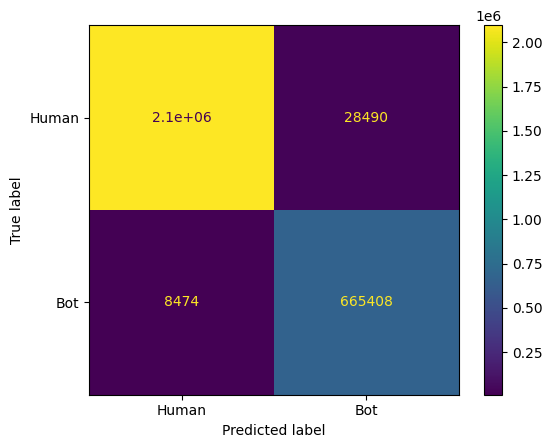

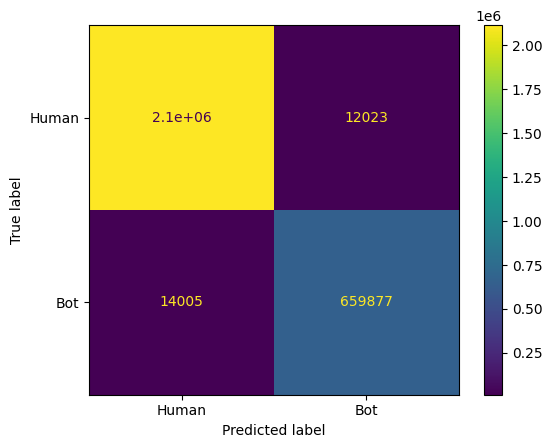

In [13]:
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import time

model.eval() # Chuyển sang chế độ kiểm tra
all_preds = []
all_labels = []

# ---------------------------------------------------------
# 1. XGBOOST INFERENCE
# ---------------------------------------------------------
start_time = time.time()
# XGBoost nuốt trọn ma trận Numpy cực nhanh
xgb_preds = xgb_model.predict(X_test_ml) 
xgb_infer_time = time.time() - start_time
print(f"[XGBoost] Thời gian Inference: {xgb_infer_time:.4f} giây")

# In báo cáo chi tiết
print("--- BÁO CÁO KẾT QUẢ ---")
print(classification_report(y_test_ml, xgb_preds))

ConfusionMatrixDisplay.from_predictions(
    y_test_ml,
    xgb_preds,
    display_labels=["Human", "Bot"]
)

# ---------------------------------------------------------
# 2. TRANSFORMER INFERENCE
# ---------------------------------------------------------
start_time = time.time()
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        probs = torch.sigmoid(outputs)
        # Chuyển xác suất thành nhãn 0 hoặc 1 (ngưỡng 0.8)
        preds = (probs > 0.8).float()

        all_preds.extend(preds.cpu().numpy().ravel())
        all_labels.extend(batch_y.cpu().numpy().ravel())
transformer_infer_time = time.time() - start_time
print(f"[Transformer] Thời gian Inference: {transformer_infer_time:.4f} giây")

# In báo cáo chi tiết
print("--- BÁO CÁO KẾT QUẢ ---")
print(classification_report(all_labels, all_preds))

ConfusionMatrixDisplay.from_predictions(
    all_labels,
    all_preds,
    display_labels=["Human", "Bot"]
)

## Export Models

Recommended formats:
- XGBoost: native JSON (`xgboost_model.json`) for reliable reload with categorical support.
- Transformer: PyTorch checkpoint (`transformer_monolithic.pt`) because the tokenizer/model are custom PyTorch modules.

Use ONNX only when deploying with ONNX Runtime and after validating predictions match the notebook. Native formats are safer for this project.


In [15]:
from pathlib import Path
import json
import torch
import numpy as np

EXPORT_DIR = Path("models")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)


def to_jsonable(value):
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (list, tuple)):
        return [to_jsonable(v) for v in value]
    if isinstance(value, dict):
        return {str(k): to_jsonable(v) for k, v in value.items()}
    return value


# 1. Export XGBoost in native JSON format.
xgb_model_path = EXPORT_DIR / "xgboost_model.json"
xgb_model.save_model(xgb_model_path)

# 2. Export Transformer checkpoint with enough metadata to rebuild the model.
transformer_path = EXPORT_DIR / "transformer_monolithic.pt"
model_cpu = model.to("cpu")
model_cpu.eval()

checkpoint = {
    "model_state_dict": model_cpu.state_dict(),
    "model_class": "DoW_Classifier",
    "tokenizer_class": "MonolithicTabularTokenizer",
    "num_features": int(NUM_FEATURES),
    "vocab_size": int(VOCAB_SIZE),
    "embedding_dim": int(EMBED_DIM),
    "feature_names": list(feature_names),
    "function_id_categories": to_jsonable(FUNCTION_ID_CATEGORIES),
    "threshold": 0.8,
}
torch.save(checkpoint, transformer_path)

# 3. Small human-readable metadata file.
metadata_path = EXPORT_DIR / "model_metadata.json"
metadata = {
    "xgboost_model": str(xgb_model_path),
    "transformer_model": str(transformer_path),
    "num_features": int(NUM_FEATURES),
    "vocab_size": int(VOCAB_SIZE),
    "embedding_dim": int(EMBED_DIM),
    "feature_names": list(feature_names),
    "function_id_categories": to_jsonable(FUNCTION_ID_CATEGORIES),
    "transformer_threshold": 0.8,
}
metadata_path.write_text(json.dumps(to_jsonable(metadata), indent=4), encoding="utf-8")

# Move model back to the original device if you continue using this notebook.
model = model_cpu.to(device)

print(f"[OK] XGBoost saved to: {xgb_model_path}")
print(f"[OK] Transformer saved to: {transformer_path}")
print(f"[OK] Metadata saved to: {metadata_path}")


[OK] XGBoost saved to: models/xgboost_model.json
[OK] Transformer saved to: models/transformer_monolithic.pt
[OK] Metadata saved to: models/model_metadata.json
